# Pytorch FSDP fine tune Llama 3.1 on AMD GPUs with ROCm

[Pytorch Fully Sharded Data Parallel (FSDP)](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/viewer.html?pdfurl=https%3A%2F%2Farxiv.org%2Fpdf%2F2304.11277&tabId=1083467778&clen=1032702&chunk=true&pdffilename=2304.11277v2.pdf) is a data parallelism technique that enables the training of large-scale models in a memory-efficient manner. FSDP achieved this by sharding model parameters, optimizer states, and/or gradients across GPUs, reducing each GPU's required memory footprint. This enables the training of large-scale models with lower total GPU memory than DDP, in which the model weights and optimizer states are replicated across all processes. You can explore more about DDP in our  [DDP](https://github.com/ROCm/rocm-blogs/tree/release/blogs/artificial-intelligence/ddp-training). 

In this blog, we will guide you through the process of using PyTorch FSDP to fine-tune the Llama model efficiently on an AMD GPU cluster with ROCm.

<!-- ## Llama3.1  
The recent release of [Llama 3.1](https://llama.meta.com/) brings models with remarkable performance, delivering quality on par with leading language models like GPT-4 across a wide range of tasks. This advancement significantly narrows the gap between closed-source models and open-weight alternatives. Instead of relying on frozen, general-purpose LLMs such as GPT-4, Claude 3, and Gemini, Llama 3.1 can be fine-tuned for specific use cases, offering better performance and customizability at a lower cost. 

The Llama 3.1 release introduces six new open LLM models based on the Llama 3 architecture. They come in three sizes: 8B, 70B, and 405B parameters, each with base (pre-trained) and instruct-tuned versions. Compared to its ancestor Llam3, Llama3.1 expands context length to 128k, enhances Multilingual support, shows strong performance in tool usage benchmarks, etc. For more details please refer to the [The Llama 3 Herd of Models](https://arxiv.org/abs/2407.21783). -->


## Pytorch Fully Sharded Data Parallel (FSDP)
[PyTorch Fully Sharded Data Parallel (FSDP)](https://pytorch.org/docs/stable/fsdp.html) provides the flexibility of sharding model parameters, optimizer states, and/or gradients across GPUs. This ensures that only a portion of the model's parameters is held on each GPU. FSDP wraps model layers in a nested structure, ensuring that only the layers within a specific FSDP instance need to gather full parameters on a single device during the forward and backward passes. Once the computation for a layer is completed, the gathered parameters are immediately freed, retaining only the original shard of the parameters. This process frees up memory for the next layer's computation, significantly reducing peak GPU memory usage. As a result, FSDP allows for training larger models or using larger batch sizes.

The memory requirements for FSDP are proportional to the size of the sharded model plus the largest fully-materialized FSDP instance. To further optimize memory efficiency, FSDP can offload parameters, gradients, and optimizer states to the CPU when a specific instance is not involved in the computation.

### FSDP workflow

* Foward Path: An FSDP instance, which may consist of one or more layers, performs an all-gather operation to collect parameter shards from all ranks, assembling the full parameters for that instance on each rank. Each rank then runs forward computation on the FSDP instance using its exclusive batch of data. After computation, parameter shards not belonging to the rank are freed. This process repeats for each FSDP instance until the forward pass is complete.
* Backward path: Starting from the last FSDP instance, the process begins by all-gathering parameters from all ranks. Backward computation is then executed to calculate gradients for that instance. Next, a reduce_scatter operation is performed, where gradients from all ranks are averaged and sharded back across the ranks. As in the forward pass, any parameters not belonging to the rank are released. This process continues for all FSDP instances until gradients are calculated and distributed across all ranks. Finally, the optimizer updates the weights in parallel for each rank using the calculated gradients.

#### Sharding strategy  
While FSDP reduces memory usage during training, it introduces communication overhead due to parameter gathering, release, and synchronization across workers. FSDP provides several sharding strategies to optimize memory efficiency and GPU communication, each suited to different model sizes and computational requirements:

* FULL_SHARD: Fully shards parameters, gradients, and optimizer states across workers, requiring the most communication during forward and backward passes.
* SHARD_GRAD_OP: Shards only gradients and optimizer states, while keeping parameters unsharded during computation. Parameters are unsharded before the forward pass, remain unsharded after it, and are only resharded after the backward pass. This approach reduces memory traffic related to parameter gathering and release.
* `NO_SHARD`: A replica of the model is kept across workers and synchronizing gradients after the backward pass. This strategy is useful when communication is a bottleneck and sufficient memory is available.
* `HYBRID_SHARD`: Combines FULL_SHARD within a single node with parameter replication across nodes, balancing inter-node communication and memory usage for medium-sized models.
* `_HYBRID_SHARD_ZERO2`: Similar to `HYBRID_SHARD`, but applies `SHARD_GRAD_OP` within a node, offering higher throughput at the cost of increased peak memory usage.

These strategies empower users to optimize their training setups, balancing memory usage and throughput according to their specific needs.

### Sharding polices 
FSDP provides flexible sharding policies. Users can specify module classes (e.g., transformer blocks) to be wrapped as FSDP instances, which are then sharded across ranks. Additionally, users can set size limits for wrapping, where layers are only wrapped or sharded if their parameter count exceeds the specified threshold. Users also have the option to define custom sharding policies. These features enable users to tailor their strategy, balancing memory usage and communication overhead to suit their needs.


For more detailed information please refer to the Pytorch [FSDP APIs](https://pytorch.org/docs/stable/fsdp.html).


## Setup

This blog was created using the following setup. For comprehensive support details about the setup, please refer to the [ROCm documentation](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/).

* Hardware & OS:
  * [AMD Instinct GPU](https://www.amd.com/en/products/accelerators/instinct.html)
  * Ubuntu 22.04.3 LTS
* Software:
  * [ROCm 6.1+](https://rocm.docs.amd.com/projects/install-on-linux/en/develop/how-to/amdgpu-install.html)
  * [PyTorch 2.1+ for ROCm](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/how-to/3rd-party/pytorch-install.html)
  
In this blog, we perform the experiment using the [`rocm/pytorch:rocm6.2.1_ubuntu20.04_py3.9_pytorch_release_2.3.0`](https://hub.docker.com/layers/rocm/pytorch/rocm6.2_ubuntu20.04_py3.9_pytorch_release_2.3.0/images/sha256-a1b2be0e705b02c25a3cf7fdaa991afea68deaebcafa58ef1872ce961713617c) Docker image on **4** nodes of [**Oracle Cloud Infrastructure (OCI)**](https://www.oracle.com/ai-infrastructure/), with each node featuring **8 MI300x** GPUs.


## Getting Started

Thanks to Meta’s open-source contributions, the experiments in this blog are based on the [Llama recepites](https://github.com/meta-llama/llama-recipes) project. In this blog, we focus on using the `FULL_SHARD` strategy to fine-tune 8B and 70B models on AMD GPUs with ROCm on OCI. 

Implementing FSDP requires some code modifications and the necessary changes will be highlighted in the sections that follow.

`FSDP` depends on the Pytorch Distributed communication package - [`torch.distributed`](https://pytorch.org/docs/stable/distributed.html) to offer support and communication primitives for multiprocess parallelism across multiple computation nodes, either on a single machine or across several machines. The first step is to initialize both the default distributed process group and the distributed package.

In [ ]:
import torch.distributed as dist
# nccl is recommended by pytorch for distributed GPU training
dist.init_process_group(backend="nccl") 

After the setup, the local and global rank id can be gotten with the following.

In [ ]:
local_rank = int(os.environ["LOCAL_RANK"])
rank = int(os.environ["RANK"])

To use `FSDP` on a host with N GPUs, N processes should be spawned, with each process assigned to a specific GPU, ranging from 0 to N-1. This can be achieved by calling: This ensures that the FSDP instance’s compute device is the destination device. 

In [ ]:
torch.cuda.set_device(local_rank)

When preparing the dataset for distributed training, it is important to ensure that each rank receives a unique subset of the dataset during training. This can be achieved by passing a `DistributedSampler` instance to the `sampler` argument of `torch.utils.data.DataLoader()`.

In [ ]:
# create dataset
dataset_train=get_preprocessed_dataset(...) 
train_dataloader = torch.utils.data.DataLoader(dataset_train, sampler=DistributedSampler(dataset_train), ...)

Pytorch provides a concise API [FullyShardedDataParallel](https://pytorch.org/docs/stable/fsdp.html) to convert a model as FSDP instace in a nested manner. 

In [ ]:
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp import ShardingStrategy
from transformers import LlamaForCausalLM

model = LlamaForCausalLM.from_pretrained(train_config.model_name, ...)

my_auto_wrapping_policy = fsdp_auto_wrap_policy(model, [LlamaDecoderLayer])
model = FSDP(
            model,
            auto_wrap_policy= my_auto_wrapping_policy
            sharding_strategy= ShardingStrategy.FULL_SHARD,
            ...)

FSDP allows users to specify parameters such as `size limits` and `module classes` as part of the sharding policy when wrapping a model for FSDP training. In the code snippet above, the module class `LlamaDecoderLayer` is used to instruct FSDP to convert any layer of the model that belongs to the `LlamaDecoderLayer` class into FSDP instances. 

>Note: `LlamaDecoderLayer` class defines a transformer block consisting of self-attention and MLP components. After this configuration, we can print the model to verify the changes.  

In [ ]:
print(model)

Output:
```text
 FullyShardedDataParallel(
   (_fsdp_wrapped_module): LlamaForCausalLM(
     (model): LlamaModel(
       (embed_tokens): Embedding(32000, 4096)
       (layers): ModuleList(
         (0-31): 32 x FullyShardedDataParallel(
           (_fsdp_wrapped_module): LlamaDecoderLayer(
             (self_attn): LlamaSdpaAttention(
               (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
               (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
               (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
               (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
               (rotary_emb): LlamaRotaryEmbedding()
             )
             (mlp): LlamaMLP(
               (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
               (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
               (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
               (act_fn): SiLU()
             )
             (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
             (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
           )
         )
       )
       (norm): LlamaRMSNorm((4096,), eps=1e-05)
       (rotary_emb): LlamaRotaryEmbedding()
     )
     (lm_head): Linear(in_features=4096, out_features=32000, bias=False)
   )
 )
 ```

This Llama 2 8B model consists of 32 layers of `LlamaDecoderLayer`, and each layer has been correctly wrapped as an FSDP instance.

After this, the model wrapped with FSDP can be used like a normal model during training. Once training is complete, it is recommended to clean up the process group that was created at the beginning.

In [ ]:
"""Clean up the process group after training"""
dist.destroy_process_group()

## <h3 id="Multi-GPU-and-Multi-Node-Training">Multi-GPU and Multi-Node Training</h3>

To launch distributed training with FSDP across multiple nodes, the same Docker container and training command should be executed on each node. This process is similar to using DDP for training. For detailed instructions on manually launching distributed training, please refer to our [DDP blog](https://github.com/ROCm/rocm-blogs/tree/release/blogs/artificial-intelligence/ddp-training). To simplify this process, we will use [Slurm](https://slurm.schedmd.com/documentation.html) in this blog to manage the workload.

The first step is to download the code and dataset used for fine-tuning Llama models. We assume you have a shared file system and will run the following commands in the shared folder accessible by all the nodes.

In [ ]:
%%bash
# clone the repo for this blog
git clone https://github.com/ROCm/rocm-blogs.git
cd rocm-blogs/blogs/artificial-intelligence/fsdp-training-pytorch/src

# git clone llama-recipes
git clone https://github.com/meta-llama/llama-recipes.git
cp *.sh llama-recipes

# Download dataset for fine-tuning
cd llama-recipes
wget -P src/llama_recipes/datasets https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json

lama 2 models need to be downloaded. Access to the Llama 2 models requires a request. Please follow the [Llama-2-7b-hf page](https://huggingface.co/meta-llama/Llama-2-7b-hf) and [Llama-2-70b-hf page](https://huggingface.co/meta-llama/Llama-2-70b-hf) page to obtain access. Once granted, you can download the models using the command below by providing your Hugging Face account token as outlined.

In [ ]:
%%bash
pip install git+https://github.com/huggingface/huggingface_hub
huggingface-cli login

You will see the following ouput:

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 

Enter your Hugging Face account token to log in. Then run the fllowing commands to download `Llama-2-7b-hf` and `Llama-2-70b-hf`. 

In [ ]:
%bash
cd llama-recipes
huggingface-cli download meta-llama/Llama-2-7b-hf  --local-dir meta-llama/Llama-2-7b-hf
huggingface-cli download meta-llama/Llama-2-70b-hf  --local-dir meta-llama/Llama-2-70b-hf

At this point, it's ready to launch the FSDP fine-tuning of 'Llama-2-7b-hf' and 'Llama-2-70b-hf' with different GPUs or nodes in `OCI`.

### Singel node FSDP fine-tuning with Slurm

There are several benefits to using [Slurm](https://slurm.schedmd.com/overview.html) for your job. It allows for exclusive node access without concerns about contention and provides an easy way to execute and monitor jobs across multiple nodes. Slurm manages resource contention by maintaining a queue of jobs. Using Slurm for training generally involves three main parts: requesting nodes, setting up the environment on each node, and launching FSDP training across all nodes. The [`fsdp_ft_single_node_core.sh`](https://github.com/ROCm/rocm-blogs/tree/release/blogs/artificial-intelligence/fsdp-training-pytorch/src/fsdp_ft_single_node_core.sh) has included all these three-part. The following command can be configured to run the FSDP training on one node with various configurations.

```text
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh n_proc_per_node n_epoch n_batchsize model_path model_size save_model
```
More specifically, the following command fine-tunes the Llama-2-7b-hf model weights (using the ['alpaca_data'](https://huggingface.co/datasets/tatsu-lab/alpaca) dataset by default) on a single node (useocpm2m-386-001). It utilizes two GPUs for 1 epoch with a batch size of 16 and saves the checkpoint after fine-tuning.

In [ ]:
%%bash
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 2 1 16 ./meta-llama/Llama-2-7b-hf 2-7B True

To analyze the scalability of the FSDP training on OCI we fine-tuned 'Llama-2-7b-hf' and 'Llama-2-70b-hf' models with different number of GPUs (1,2,4,8).

In [ ]:
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 1 1 16 ./meta-llama/Llama-2-7b-hf 2-7B False
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 2 1 16 ./meta-llama/Llama-2-7b-hf 2-7B True
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 4 1 16 ./meta-llama/Llama-2-7b-hf 2-7B False
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 8 1 16 ./meta-llama/Llama-2-7b-hf 2-7B False
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 1 1 4 ./meta-llama/Llama-2-70b-hf 2-70B False
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 2 1 4 ./meta-llama/Llama-2-70b-hf 2-70B False 
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 4 1 4 ./meta-llama/Llama-2-70b-hf 2-70B False 
sbatch --nodes=1 --nodelist=useocpm2m-386-001 fsdp_ft_single_node_core.sh 8 1 4 ./meta-llama/Llama-2-70b-hf 2-70B False 

After this is completed you can find the FSDP sharded checkpoints under path "./fsdp_fine_tune_results/fsdp_model_finetuned_1_2_2-7B/fine-tuned-./meta-llama/Llama-2-7b-hf"
```text
__0_0.distcp
__1_0.distcp
.metadata
train_params.yaml
```

The following script can be used to run inference with the checkpoint.

```text
bash inference_test.sh checkpoint_path model_be_fintuned_path model_version prompt_for_test_file
```
This is a test case for running inference with the checkpoint located at "/fsdp_fine_tune_results/fsdp_model_finetuned_1_2_2-7B/fine-tuned-./meta-llama/Llama-2-7b-hf", which was obtained by fine-tuning the './meta-llama/Llama-2-7b-hf' model. `prompt_for_test.txt` contains the prompt as `Develop a plan to build a AI chatbot in a home.`


In [ ]:
bash inference_test.sh ./fsdp_fine_tune_results/fsdp_model_finetuned_1_2_2-7B/fine-tuned-./meta-llama/Llama-2-7b-hf ./meta-llama/Llama-2-7b-hf 2_7b ./prompt_for_test.txt

Output:
```text
Model name: ./meta-llama/Llama-2-7b-hf
model is loaded from config
/opt/conda/envs/py_3.9/lib/python3.9/site-packages/torch/distributed/checkpoint/state_dict_loader.py:27: UserWarning: 'load_state_dict' is deprecated and will be removed in future versions. Please use 'load' instead.
  warnings.warn(
Sharded state checkpoint loaded from ./fsdp_fine_tune_results/fsdp_model_finetuned_1_2_2-7B/fine-tuned-./meta-llama/Llama-2-7b-hf
model is loaded from FSDP checkpoints
HuggingFace model checkpoints has been saved in ./fsdp_fine_tune_results/fsdp_model_finetuned_1_2_7b_hf
use_fast_kernelsFalse
Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [02:25<00:00, 24.26s/it]
User prompt deemed safe.
User prompt:
Develop a plan to build a AI chatbot in a home.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
/opt/conda/envs/py_3.9/lib/python3.9/site-packages/transformers/models/llama/modeling_llama.py:655: UserWarning: 1Torch was not compiled with memory efficient attention. (Triggered internally at /var/lib/jenkins/pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:517.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
the inference time is 13113.63934900146 ms
User input and model output deemed safe.
Model output:
Develop a plan to build a AI chatbot at home. There are a few steps that must be taken before building an AI chatbot. First, you need to create a user interface and design how thebot will interact with the user. Second, you need to build the underlying logic of thebot and create the training database. Third, you need to test the output of thebot and make sure that it is up to par with the industry standards. Finally, you need to deploy thebot and run it at home, so that it can be used
```

We can see that the output makes sense.

### Multi-node FSDP fine-tuning with Slurm

Similarly, [`fsdp_ft_multi_node_core.sh`](https://github.com/ROCm/rocm-blogs/tree/release/blogs/artificial-intelligence/fsdp-training-pytorch/src/fsdp_ft_multi_node_core.sh) is provided to assist in requesting nodes, setting up the environment, and launching the fine-tuning process. The fine-tuning of 'Llama-2-7b-hf' and 'Llama-2-70b-hf' models with different numbers of nodes (each equipped with 8 GPUs) is explored.

In [ ]:
sbatch --nodes=2 --nodelist=useocpm2m-386-001,useocpm2m-386-002 fsdp_ft_multi_node_core.sh 8 1 16 ./meta-llama/Llama-2-7b-hf 2-7B  False
sbatch --nodes=4 --nodelist=useocpm2m-386-002,useocpm2m-386-003,useocpm2m-386-004,useocpm2m-386-006 fsdp_ft_multi_node_core.sh 8 1 16 ./meta-llama/Llama-2-7b-hf 2-7B  False
sbatch --nodes=2 --nodelist=useocpm2m-386-001,useocpm2m-386-002 fsdp_ft_multi_node_core.sh 8 1 4 ./meta-llama/Llama-2-70b-hf 2-70B False 
sbatch --nodes=4 --nodelist=useocpm2m-386-001,useocpm2m-386-002,useocpm2m-386-003,useocpm2m-386-006 fsdp_ft_multi_node_core.sh 8 1 4 ./meta-llama/Llama-2-70b-hf 2-70B False

### Results analysis

During the fine-tuning of the `Llama-2-7b-hf` and `Llama-2-70b-hf` models on varying numbers of GPUs and nodes, the `maximum CUDA memory` reserved, `epoch time`, and `step time` was recorded. These three metrics are summarized in the below plots. The `batch size` (bs) for a single GPU is set to `16` for `Llama-2-7b-hf` and `4` for `Llama-2-70b-hf`. We maintain the same batch size for a single GPU regardless of the number of GPUs or nodes used. This approach ensures that the number of GPUs is the only variable in the experiment, helping us understand the behavior of FSDP training to the number of GPUs utilized
> **Note**:
> Fine-tune `Llama-2-70b-hf` with bath size as 4 will cause out-of-memory using 1 and 2 GPUs. We put `OOM` for that on the plots for that.

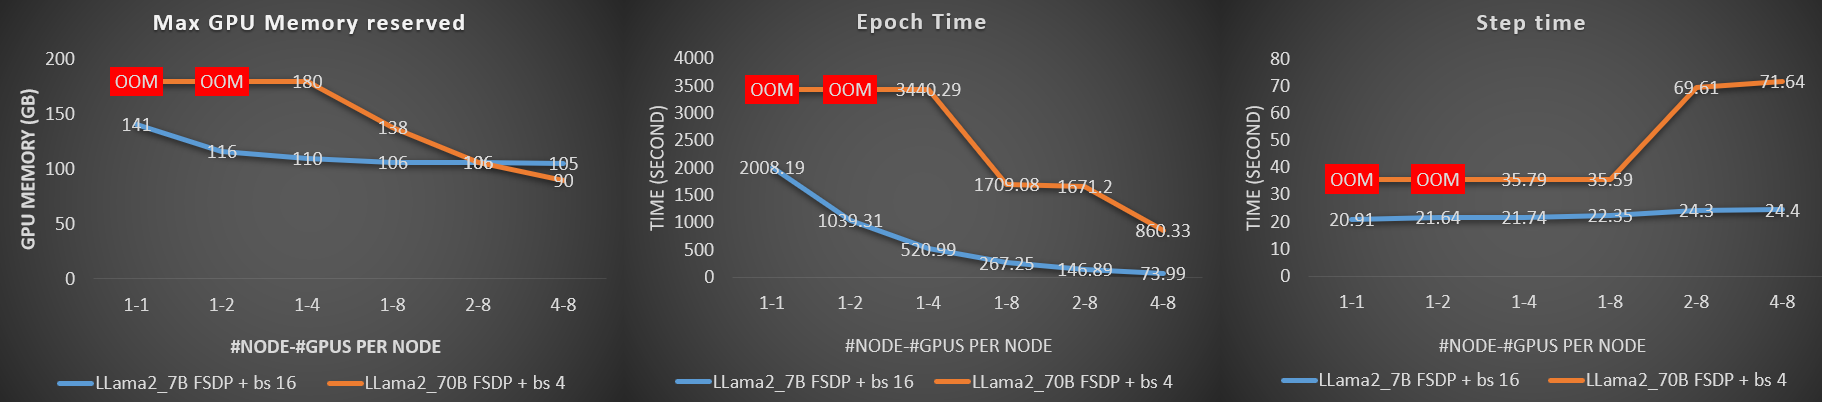

* Memory saving
    * From the first plot, the overall trend shows that as more GPUs are utilized, the memory required on a single GPU decreases. This reduction in memory is more pronounced for larger models. The nature of FSDP explains this phenomenon: model weights are shared across the GPUs, meaning that with more GPUs in use, each GPU needs to hold fewer weights.
    * When scaling up the training to a certain number of GPUs, the memory consumed by the sharded weights on a single GPU becomes negligible compared to the total memory required. This is why, for the smaller model, `Llama-2-7b-hf`, the memory savings are not as significant when the number of GPUs exceeds eight.
    * The saved memory can be utilized to increase the batch size. This is why we can fine-tune Llama-2-70b-hf on more than two GPUs but cannot do so with two or fewer GPUs. FSDP enables the training of large models on multiple GPUs and nodes, which is not feasible on a single GPU.
      
* Training time
    * The epoch time indicates how long it takes to train the model on the entire dataset. The middle plot shows that the time required for one epoch decreases as more GPUs are employed. During fine-tuning, each process/GPU handles a batch of data for computation. With N GPUs, the effective batch size processed in parallel is N times that of a single GPU, accelerating the training process.
      
* Communication
    * Compared to DDP, FSDP entails more communication for operations such as all-gathering parameters and reduce-scattering gradients for each FSDP instance. When there is substantial communication between GPUs, it can reduce scaling efficiency. In the right plot, although each GPU processes the same batch size during each step (involving a forward and backward pass), the required time increases due to the additional synchronization needed among more workers.

## Disclaimers

Third-party content is licensed to you directly by the third party that owns the content and is not licensed to you by AMD. ALL LINKED THIRD-PARTY CONTENT IS PROVIDED “AS IS” WITHOUT A WARRANTY OF ANY KIND. USE OF SUCH THIRD-PARTY CONTENT IS DONE AT YOUR SOLE DISCRETION AND UNDER NO CIRCUMSTANCES WILL AMD BE LIABLE TO YOU FOR ANY THIRD-PARTY CONTENT. YOU ASSUME ALL RISK AND ARE SOLELY RESPONSIBLE FOR ANY DAMAGES THAT MAY ARISE FROM YOUR USE OF THIRD-PARTY CONTENT.

